In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')   # unnecessary warnings hide karne ke liye

In [3]:
df = pd.read_csv('Ice_cream selling data.csv')

In [4]:
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [5]:
median_sales = df['Ice Cream Sales (units)'].median()
df['High_Sales'] = (df['Ice Cream Sales (units)'] > median_sales).astype(int)

# Check the class distribution
print(df['High_Sales'].value_counts())

High_Sales
0    25
1    24
Name: count, dtype: int64


1978

In [7]:
x = df.drop('Temperature (°C)',axis=1)
y = df['High_Sales']

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.20, random_state=42)

In [9]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [10]:
Model = LogisticRegression()
Model.fit(x,y)

LogisticRegression()

In [12]:
print("Intercept:", Model.intercept_[0])
print("Coefficient:", Model.coef_[0][0])

Intercept: -14.540225013814
Coefficient: 1.050566657928358


In [16]:
y_pred = Model.predict(x_test)
y_pred

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 0])

In [20]:
y_prob = Model.predict_proba(x_test)[:, 1]
y_prob

array([1.76183328e-02, 9.91824497e-01, 9.99999737e-01, 9.99999927e-01,
       9.26424654e-03, 5.50737360e-06, 1.11093768e-06, 6.24782301e-05,
       7.97459378e-05, 6.57061718e-05])

In [21]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


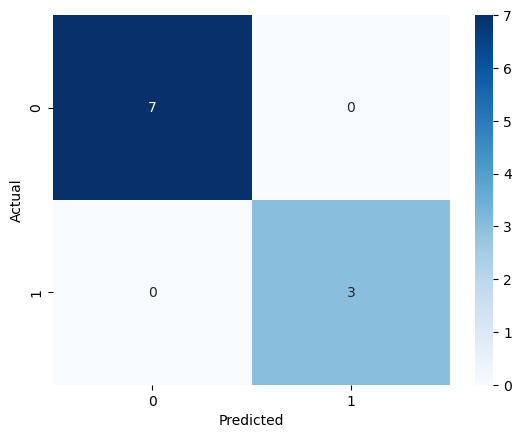

In [22]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



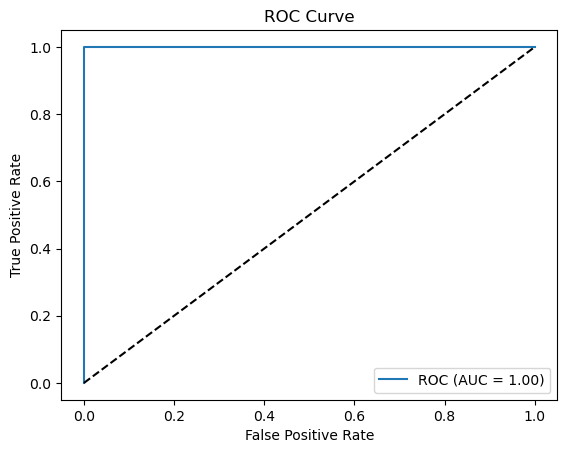

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

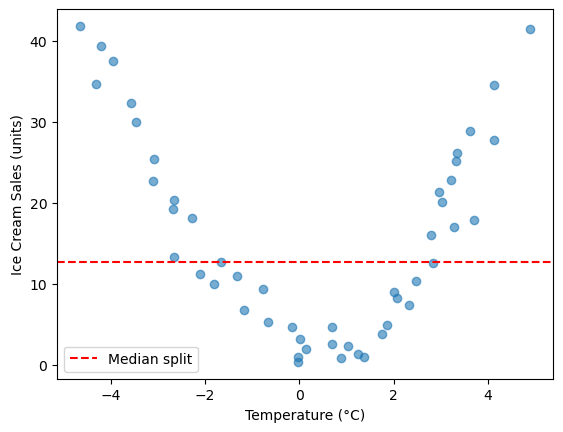

In [26]:
plt.scatter(df['Temperature (°C)'], df['Ice Cream Sales (units)'], alpha=0.6)
plt.axhline(median_sales, color='red', linestyle='--', label='Median split')
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units)')
plt.legend()
plt.show()